<a href="https://colab.research.google.com/github/JananiGovuri/Natural-Language-Processing-/blob/main/HW4Code2_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Input Tokens:
 tensor([[ 2,  3,  0,  0],
        [22, 21, 18,  0],
        [ 9, 20,  8,  1],
        [15,  8,  4,  0],
        [ 0,  8,  6,  0],
        [ 2,  7, 20,  0],
        [11,  8, 16, 10],
        [17,  3, 14,  0],
        [12, 19, 13,  0],
        [ 5,  8,  4,  0]])

Final Contextual Embeddings Shape: torch.Size([10, 4, 32])


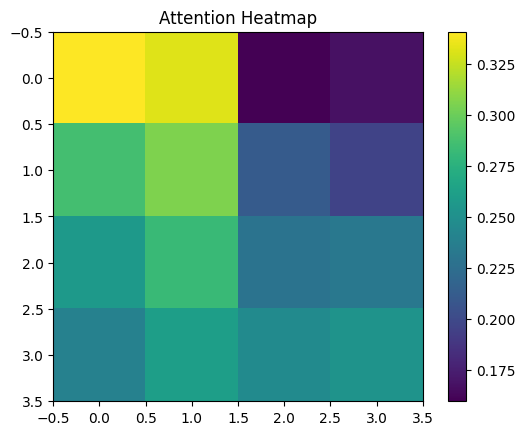

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

# -------------------------------
# 1. Sample Dataset (10 sentences)
# -------------------------------
sentences = [
    "i love nlp",
    "transformers are powerful",
    "deep learning is fun",
    "attention is important",
    "nlp is interesting",
    "i enjoy learning",
    "this is a model",
    "we love ai",
    "models learn patterns",
    "data is important"
]

# -------------------------------
# 2. Tokenization
# -------------------------------
words = list(set(" ".join(sentences).split()))
word2idx = {w: i for i, w in enumerate(words)}
idx2word = {i: w for w, i in word2idx.items()}

def tokenize(sentence):
    return [word2idx[w] for w in sentence.split()]

tokenized_data = [tokenize(s) for s in sentences]

# Padding
max_len = max(len(seq) for seq in tokenized_data)

def pad(seq):
    return seq + [0]*(max_len - len(seq))

inputs = torch.tensor([pad(seq) for seq in tokenized_data])

print("Input Tokens:\n", inputs)

# -------------------------------
# 3. Embedding Layer
# -------------------------------
d_model = 32
embedding = nn.Embedding(len(words), d_model)
x = embedding(inputs)

# -------------------------------
# 4. Positional Encoding
# -------------------------------
def positional_encoding(max_len, d_model):
    pe = torch.zeros(max_len, d_model)
    for pos in range(max_len):
        for i in range(0, d_model, 2):
            pe[pos, i] = math.sin(pos / (10000 ** ((2*i)/d_model)))
            pe[pos, i+1] = math.cos(pos / (10000 ** ((2*i)/d_model)))
    return pe

pe = positional_encoding(max_len, d_model)
x = x + pe

# -------------------------------
# 5. Multi-Head Attention
# -------------------------------
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, heads=2):
        super().__init__()
        self.heads = heads
        self.d_k = d_model // heads

        self.q_linear = nn.Linear(d_model, d_model)
        self.k_linear = nn.Linear(d_model, d_model)
        self.v_linear = nn.Linear(d_model, d_model)
        self.out = nn.Linear(d_model, d_model)

    def forward(self, x):
        B, T, C = x.size()

        Q = self.q_linear(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        K = self.k_linear(x).view(B, T, self.heads, self.d_k).transpose(1,2)
        V = self.v_linear(x).view(B, T, self.heads, self.d_k).transpose(1,2)

        scores = torch.matmul(Q, K.transpose(-2,-1)) / math.sqrt(self.d_k)
        attn = torch.softmax(scores, dim=-1)

        out = torch.matmul(attn, V)
        out = out.transpose(1,2).contiguous().view(B, T, C)
        return self.out(out), attn

# -------------------------------
# 6. Feed Forward Layer
# -------------------------------
class FeedForward(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.fc1 = nn.Linear(d_model, 64)
        self.fc2 = nn.Linear(64, d_model)

    def forward(self, x):
        return self.fc2(F.relu(self.fc1(x)))

# -------------------------------
# 7. Transformer Encoder Block
# -------------------------------
class EncoderBlock(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.attn = MultiHeadAttention(d_model)
        self.norm1 = nn.LayerNorm(d_model)
        self.ff = FeedForward(d_model)
        self.norm2 = nn.LayerNorm(d_model)

    def forward(self, x):
        attn_out, attn_weights = self.attn(x)
        x = self.norm1(x + attn_out)

        ff_out = self.ff(x)
        x = self.norm2(x + ff_out)

        return x, attn_weights

# -------------------------------
# 8. Run Encoder
# -------------------------------
encoder = EncoderBlock(d_model)
output, attn_weights = encoder(x)

print("\nFinal Contextual Embeddings Shape:", output.shape)

# -------------------------------
# 9. Attention Heatmap
# -------------------------------
# Show attention for first sentence, first head
heatmap = attn_weights[0][0].detach().numpy()

plt.imshow(heatmap, cmap='viridis')
plt.title("Attention Heatmap")
plt.colorbar()
plt.show()